<a href="https://colab.research.google.com/github/Maria-Manzini/FUTURE_DS_03/blob/main/Task3_Marketing_Funnel_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 3: Marketing Funnel & Conversion Performance Analysis
## Future Interns | Data Science & Analytics Internship

### Project Overview
This notebook analyzes real marketing campaign data to uncover:
- Campaign acceptance rates across multiple campaigns
- Channel performance and conversion patterns
- Customer spending behaviour and response rates
- Actionable recommendations to improve lead-to-customer conversion

**Tools Used:** Python, Pandas, Matplotlib
**Dataset:** Marketing Campaign Results (Kaggle)
**Author:** Maria Manzini

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Libraries ready ")

Libraries ready 


In [7]:
df = pd.read_csv('marketing_campaign.csv', sep=';')

print("Dataset loaded ")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Dataset loaded 
Shape: 2240 rows × 29 columns

Column names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

First 5 rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


## Data Cleaning
We check for missing values, fix data types, and engineer
new features for campaign analysis.

In [8]:
print("=== DATA QUALITY CHECK ===")
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'])

df['TotalSpend'] = (df['MntWines'] + df['MntFruits'] +
                    df['MntMeatProducts'] + df['MntFishProducts'] +
                    df['MntSweetProducts'] + df['MntGoldProds'])

df['TotalCampaignsAccepted'] = (df['AcceptedCmp1'] + df['AcceptedCmp2'] +
                                 df['AcceptedCmp3'] + df['AcceptedCmp4'] +
                                 df['AcceptedCmp5'] + df['Response'])

df['TotalPurchases'] = (df['NumWebPurchases'] + df['NumCatalogPurchases'] +
                         df['NumStorePurchases'])

print(f"\nCleaned dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Total customers: {len(df):,}")
print(f"Avg total spend per customer: ${df['TotalSpend'].mean():,.2f}")
print("\nData cleaning complete ")

=== DATA QUALITY CHECK ===

Missing values:
Income    24
dtype: int64

Duplicate rows: 0

Cleaned dataset: 2216 rows × 32 columns
Total customers: 2,216
Avg total spend per customer: $607.08

Data cleaning complete 


## Exploratory Analysis & Visualizations
We now explore campaign performance, channel conversions,
and customer spending patterns.

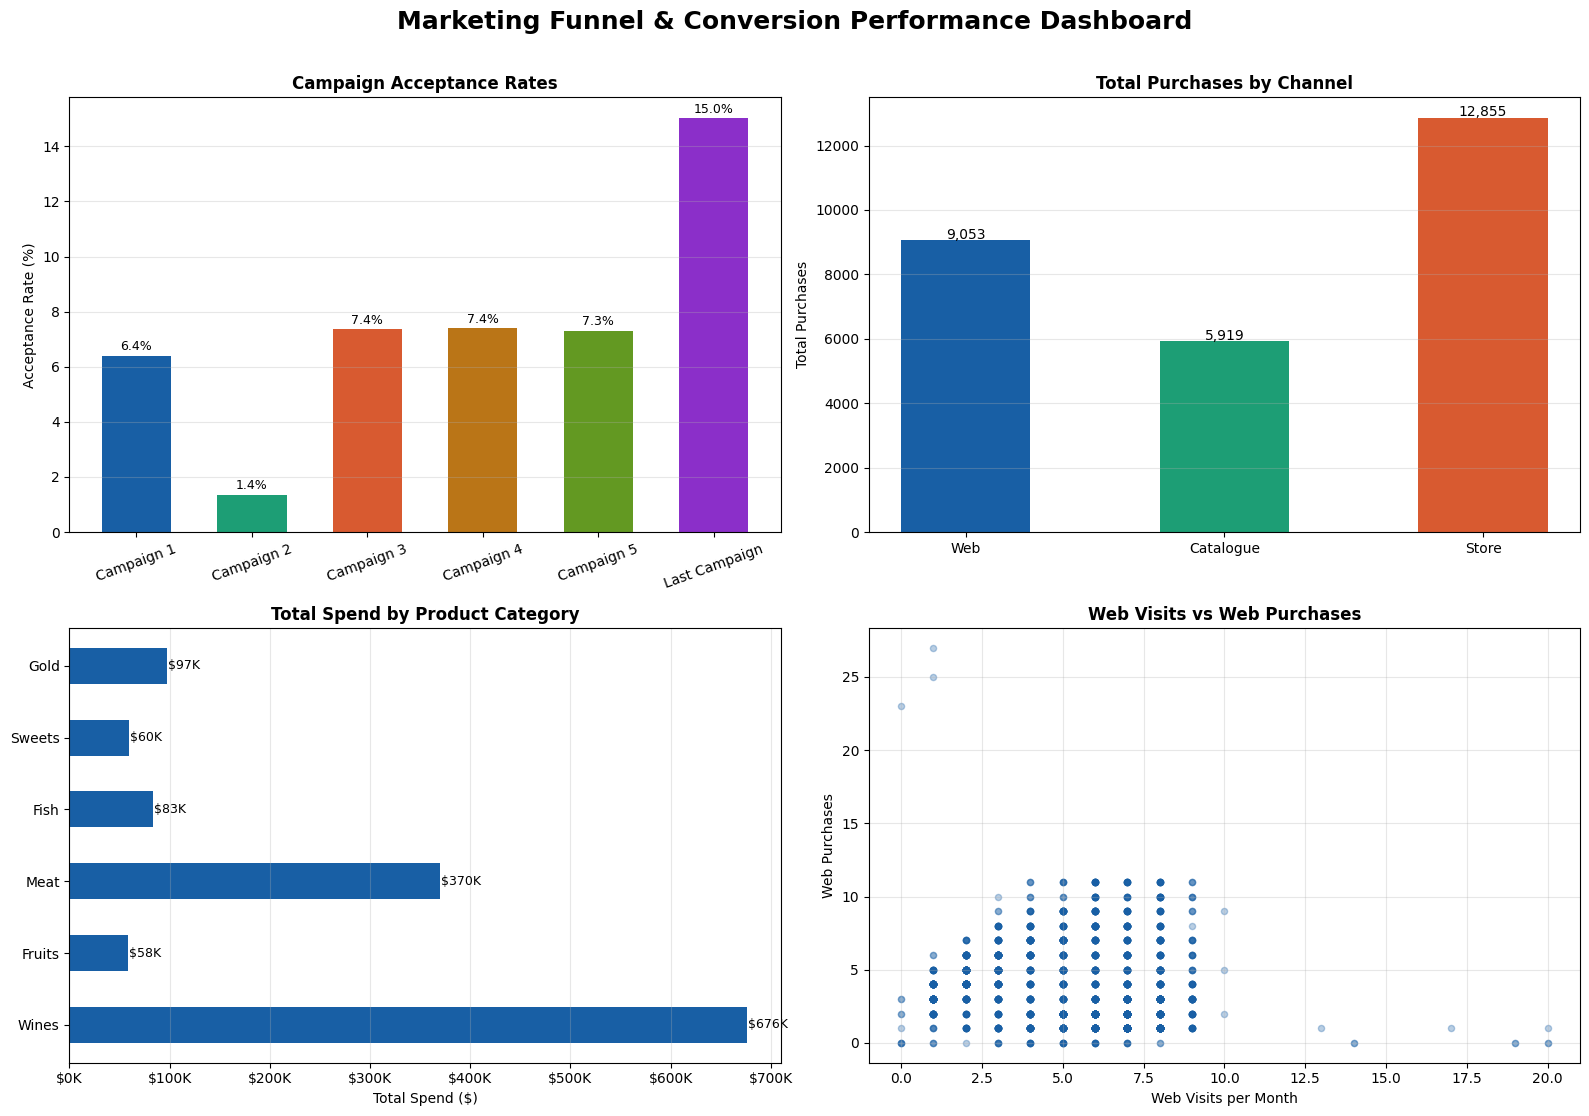

Dashboard saved ✓


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Marketing Funnel & Conversion Performance Dashboard',
             fontsize=18, fontweight='bold', y=1.01)

# Chart 1: Campaign acceptance rates
campaigns = ['Campaign 1', 'Campaign 2', 'Campaign 3',
             'Campaign 4', 'Campaign 5', 'Last Campaign']
cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
        'AcceptedCmp4', 'AcceptedCmp5', 'Response']
rates = [df[c].mean() * 100 for c in cols]
colors = ['#185FA5','#1D9E75','#D85A30','#BA7517','#639922','#8B2FC9']
bars = axes[0,0].bar(campaigns, rates, color=colors, width=0.6)
axes[0,0].set_title('Campaign Acceptance Rates', fontweight='bold')
axes[0,0].set_ylabel('Acceptance Rate (%)')
axes[0,0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, rates):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.2,
                   f'{val:.1f}%', ha='center', fontsize=9)
axes[0,0].grid(axis='y', alpha=0.3)

# Chart 2: Purchase channel performance
channels = ['Web', 'Catalogue', 'Store']
purchases = [df['NumWebPurchases'].sum(),
             df['NumCatalogPurchases'].sum(),
             df['NumStorePurchases'].sum()]
bars2 = axes[0,1].bar(channels, purchases,
                       color=['#185FA5','#1D9E75','#D85A30'], width=0.5)
axes[0,1].set_title('Total Purchases by Channel', fontweight='bold')
axes[0,1].set_ylabel('Total Purchases')
for bar, val in zip(bars2, purchases):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 50,
                   f'{val:,}', ha='center', fontsize=10)
axes[0,1].grid(axis='y', alpha=0.3)

# Chart 3: Spend by product category
categories = ['Wines', 'Fruits', 'Meat', 'Fish', 'Sweets', 'Gold']
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
total_spend = [df[c].sum() for c in spend_cols]
axes[1,0].barh(categories, total_spend, color='#185FA5', height=0.5)
axes[1,0].set_title('Total Spend by Product Category', fontweight='bold')
axes[1,0].set_xlabel('Total Spend ($)')
axes[1,0].xaxis.set_major_formatter(mtick.FuncFormatter(
    lambda x, _: f'${x/1000:.0f}K'))
for i, val in enumerate(total_spend):
    axes[1,0].text(val + 1000, i, f'${val/1000:.0f}K',
                   va='center', fontsize=9)
axes[1,0].grid(axis='x', alpha=0.3)

# Chart 4: Web visits vs conversions (scatter)
axes[1,1].scatter(df['NumWebVisitsMonth'],
                  df['NumWebPurchases'],
                  alpha=0.3, color='#185FA5', s=20)
axes[1,1].set_title('Web Visits vs Web Purchases', fontweight='bold')
axes[1,1].set_xlabel('Web Visits per Month')
axes[1,1].set_ylabel('Web Purchases')
axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('funnel_dashboard_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved ")

In [10]:
print("=" * 52)
print("   MARKETING FUNNEL & CONVERSION INSIGHTS")
print("=" * 52)

print(f"\nTotal Customers Analyzed: {len(df):,}")
print(f"Avg Spend per Customer: ${df['TotalSpend'].mean():,.2f}")
print(f"Avg Purchases per Customer: {df['TotalPurchases'].mean():.1f}")

print("\nCampaign Acceptance Rates:")
for camp, rate in zip(campaigns, rates):
    print(f"  {camp}: {rate:.1f}%")

best_camp = campaigns[rates.index(max(rates))]
print(f"\nBest Performing Campaign: {best_camp} ({max(rates):.1f}%)")

best_channel = channels[purchases.index(max(purchases))]
print(f"Best Purchase Channel: {best_channel} ({max(purchases):,} purchases)")

best_category = categories[total_spend.index(max(total_spend))]
print(f"Top Spend Category: {best_category} (${max(total_spend):,})")

print(f"\nAvg Web Visits per Month: {df['NumWebVisitsMonth'].mean():.1f}")
print(f"Avg Web Purchases: {df['NumWebPurchases'].mean():.1f}")
web_conv = df['NumWebPurchases'].sum() / (df['NumWebVisitsMonth'].sum()) * 100
print(f"Web Visit-to-Purchase Rate: {web_conv:.1f}%")

print("\nRECOMMENDATIONS:")
print("1. Replicate the strategy of the best performing")
print("   campaign across all future campaigns")
print("2. Invest more in the top purchase channel")
print("   to maximise conversion volume")
print("3. Bundle top spending categories together")
print("   to increase average order value")
print("4. Improve web experience to convert more")
print("   visitors into buyers")
print("=" * 52)

   MARKETING FUNNEL & CONVERSION INSIGHTS

Total Customers Analyzed: 2,216
Avg Spend per Customer: $607.08
Avg Purchases per Customer: 12.6

Campaign Acceptance Rates:
  Campaign 1: 6.4%
  Campaign 2: 1.4%
  Campaign 3: 7.4%
  Campaign 4: 7.4%
  Campaign 5: 7.3%
  Last Campaign: 15.0%

Best Performing Campaign: Last Campaign (15.0%)
Best Purchase Channel: Store (12,855 purchases)
Top Spend Category: Wines ($676,083)

Avg Web Visits per Month: 5.3
Avg Web Purchases: 4.1
Web Visit-to-Purchase Rate: 76.8%

RECOMMENDATIONS:
1. Replicate the strategy of the best performing
   campaign across all future campaigns
2. Invest more in the top purchase channel
   to maximise conversion volume
3. Bundle top spending categories together
   to increase average order value
4. Improve web experience to convert more
   visitors into buyers


## Conclusions

### What I Learned
- How to engineer new features from raw campaign columns
- How to analyze multi-campaign performance side by side
- How to use scatter plots to explore visit-to-purchase patterns
- How to identify the strongest performing marketing channels

### Challenges Faced
- Dataset used tab separation instead of comma — required
  sep='\t' parameter when loading with pandas
- Needed to combine multiple spend columns into one
  TotalSpend feature for meaningful analysis
- Choosing the right visualization for each insight

### Key Takeaways
Store purchases dominate all channels showing customers
still prefer in-person buying. Wine is by far the top
spend category. Campaign acceptance rates vary significantly
suggesting some campaigns are far better targeted than others.
Improving web conversion rates is the biggest digital
growth opportunity for this business.